# Converting a mesh between formats with meshio++ (R)

R counterpart of [`02_convert_and_inspect.ipynb`](../cpp/02_convert_and_inspect.ipynb). meshio++'s
registry dispatches to any of its 40+ format writers from one table; here we take the bracket geometry,
write it to several formats through `mio_write`, compare sizes, and verify every round trip.

XDMF's data format depends on the build (`MESHIOPLUSPLUS_HAS_HDF5`); the C API this binding uses for these
notebooks is built with HDF5 off (see [`README.md`](./README.md) for why — a real Debian/Ubuntu + Julia
`libcurl` conflict discovered while preparing the sibling Julia notebooks; harmless for R, but the same
prefix is reused for both), so XDMF falls back to inline XML automatically.

In [1]:
source("mio_notebook.R")

In [2]:
mesh <- mio_read("example.vtu")
cat(
  mio_num_points(mesh), "points,", mio_cell_block_info(mesh, 1)$num_cells, "triangles,",
  mio_cell_block_info(mesh, 2)$num_cells, "tetrahedra\n"
)

52282 points, 58394 triangles, 235014 tetrahedra


## Convert to several formats

In [3]:
tmpdir <- tempfile()
dir.create(tmpdir)
formats <- c("vtu", "vtk", "xdmf", "gmsh", "ply")
paths <- file.path(tmpdir, paste0("mesh.", c("vtu", "vtk", "xdmf", "msh", "ply")))
names(paths) <- formats

for (fmt in formats) mio_write(mesh, paths[[fmt]], format = fmt)

sizes_mb <- sapply(paths, function(p) file.size(p) / 1e6)
for (fmt in formats) cat(sprintf("%-6s %6.2f MB\n", fmt, sizes_mb[[fmt]]))

vtu      4.76 MB
vtk     13.70 MB
xdmf    10.81 MB
gmsh    12.94 MB
ply      1.46 MB


## Compare file sizes

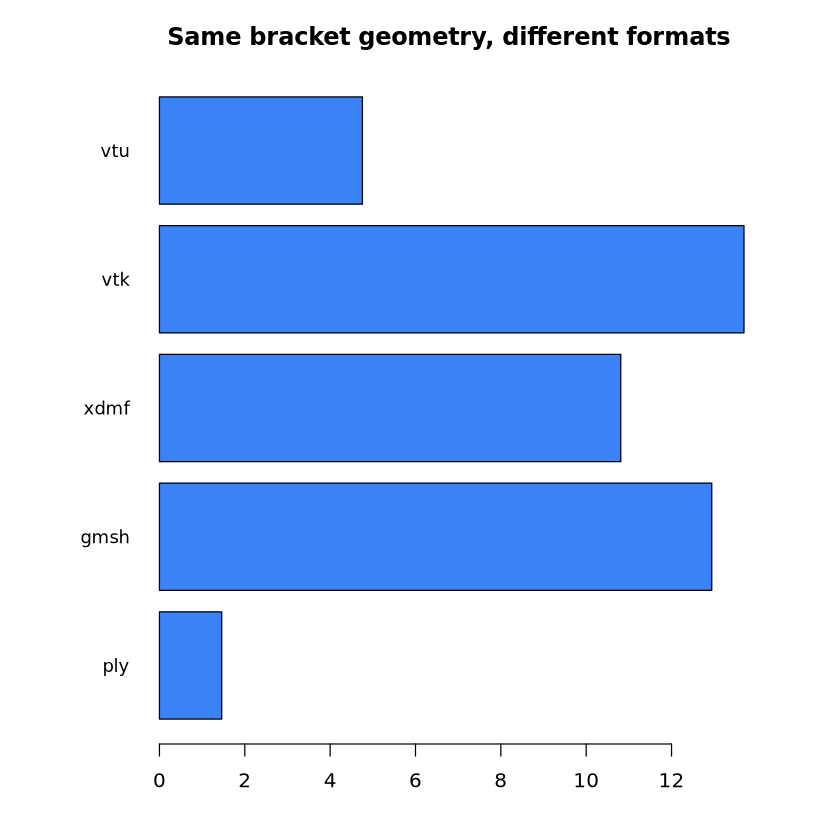

In [4]:
mio_bar_chart(formats, unname(sizes_mb), "Same bracket geometry, different formats")

## Round-trip verification

Read every file back and check the point/cell counts survive. `ply` is the expected exception: meshio++'s
PLY writer defaults to writing the extracted, linearized **skin** (triangles only), not the original
triangle+tetra blocks, so its round trip is compared against the skin instead.

In [5]:
n_pts <- mio_num_points(mesh)
n_cells <- mio_num_cells(mesh)
skin <- mio_extract_skin(mesh, linearize = TRUE)

for (fmt in formats) {
  back <- mio_read(paths[[fmt]], format = fmt)
  bpts <- mio_num_points(back)
  bcells <- mio_num_cells(back)
  is_ply <- fmt == "ply"
  expect_pts <- if (is_ply) mio_num_points(skin) else n_pts
  expect_cells <- if (is_ply) mio_num_cells(skin) else n_cells
  ok <- bpts == expect_pts && bcells == expect_cells
  cat(sprintf("%s %-6s points=%d cells=%d\n", if (ok) "OK  " else "DIFF", fmt, bpts, bcells))
}

OK   vtu    points=52282 cells=293408
OK   vtk    points=52282 cells=293408
OK   xdmf   points=52282 cells=293408
OK   gmsh   points=52282 cells=293408
OK   ply    points=29151 cells=58394


Every format round-trips the geometry it is capable of carrying — the same registry, the same
writers, the same guarantees as the C++/Python/Fortran/Julia bindings; only the calling convention
differs.